# XGBoost 三分法模型 — 評估報告

本報告**直接載入已訓練好的模型**（`src/xgboost`，存於 MLflow），**不重新訓練**。

評估方式：
1. 從 MLflow（`sqlite:///mlflow.db`）找出最新的 `xgb_half_hour` 父 run 與其三個子模型（午餐／下午茶／晚餐）。
2. 以**與訓練時完全相同的切分**（同 `random_state=42`、同前處理、同 leakage 排除）重建 held-out 測試集。
3. 用載入的模型在測試集上預測，並與 **baseline 模型**比較表現。

> **Baseline（對照組）**：每個時段一律猜該時段**訓練集中最熱門的 slot**（most-frequent dummy）。
> 這代表「不看任何特徵、只憑該時段最常見時間」的天真猜法，是衡量模型是否真的學到東西的底線。

> 預測目標：`reservation_half_hour`（半小時時段，每 slot = 30 分鐘）。
> 業務關鍵指標：**Tolerance ±1 slot accuracy**（預測差 30 分鐘內視為命中）。

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# 確保工作目錄在專案根目錄（src/ 的相對路徑、sqlite、data 路徑皆以此為基準）
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("CWD:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 專案模組（src/xgboost = source of truth）
from src.common.model_utils import (
    init_tracking, load_config, resolve_granularity, find_nested_runs, tolerance_accuracy,
)
from src.xgboost.preprocessing import (
    load_features, fill_missing, split_data, apply_saved_encoders, NON_FEATURE_COLS,
)
from src.xgboost.inference import load_subset_artifacts

# 注意：匯入 model_utils 會把 matplotlib 後端設為 'Agg'（CLI 用），
# 這裡切回 inline，否則 notebook 不會顯示圖。
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

# 關鍵：run metadata 在 sqlite，不在 ./mlruns file store
init_tracking()
print("MLflow tracking URI:", mlflow.get_tracking_uri())

CWD: C:\Users\2200767.SYSTEX\D\Taiwei\Taiwei\RestaurantBookings


2026-06-23 11:40:14,632 - src.common.model_utils - INFO - MLflow tracking URI: sqlite:///mlflow.db


MLflow tracking URI: sqlite:///mlflow.db


## 1. 載入設定、定位已訓練模型

從 `configs/xgboost.yaml` 讀目標與子集定義，並自動選用**最新**的 `xgb_half_hour` 父 run。

In [2]:
CONFIG_PATH = "configs/xgboost.yaml"
GRANULARITY = "half_hour"

config = load_config(CONFIG_PATH)
TARGET, LEAKAGE = resolve_granularity(config, GRANULARITY)
SUBSETS = config["subsets"]            # {name: {hour_min, hour_max}}
TEST_SIZE = config["evaluation"].get("test_size", 0.2)
TOL = config["evaluation"].get("tolerance_slots", 1)

print("預測目標 target :", TARGET)
print("排除 leakage    :", LEAKAGE)
print("子集 subsets    :", list(SUBSETS.keys()))

# 找出最新 xgb_half_hour 父 run 底下的三個子模型 {子集名: run_id}
subset_runs = find_nested_runs("xgboost", parent_run_name_contains=f"xgb_{GRANULARITY}")
subset_runs

2026-06-23 11:40:14,645 - src.common.model_utils - INFO - Loaded config from configs/xgboost.yaml


預測目標 target : reservation_half_hour
排除 leakage    : ['reservation_hour', 'reservation_seconds']
子集 subsets    : ['午餐 Lunch (11-14h)', '下午茶 Afternoon (15-17h)', '晚餐 Dinner (18-23h)']


2026-06-23 11:40:16,869 - src.common.model_utils - INFO - Auto-selected parent run: xgb_half_hour (3a68fa80bd214e88afa5f925e0985c6e)


2026-06-23 11:40:16,879 - src.common.model_utils - INFO - Found 3 nested runs: ['晚餐 Dinner (18-23h)', '下午茶 Afternoon (15-17h)', '午餐 Lunch (11-14h)']


{'晚餐 Dinner (18-23h)': '79319aeabddb4aca95d005652bca2aea',
 '下午茶 Afternoon (15-17h)': 'b81282f932b04c39b1addd29d998e94a',
 '午餐 Lunch (11-14h)': '9d0acd05b9384564a38f02823408660d'}

## 2. 重建 held-out 測試集、載入模型、建立 baseline

訓練時每個子集做 80/20 隨機切分（`random_state=42`）。這裡用**完全相同的切分**取回同一批測試資料，
再用**已存的模型 + 已存的 encoders / target_encoder** 預測——模型從未見過這些測試列，且全程不呼叫 `fit`。

同時用**訓練集**算出每個時段最熱門的 slot，作為 baseline 對測試集的固定猜測。

In [3]:
def slot_label(s):
    """半小時 slot 索引 -> 可讀時間，如 22 -> '11:00'、23 -> '11:30'。"""
    s = int(round(float(s)))
    return f"{s // 2:02d}:{(s % 2) * 30:02d}"

# 與訓練相同的前處理（注意：train.py 用 strategy='drop'，此處比照）
DF = fill_missing(load_features(), strategy="drop")
print("features_ready 總列數:", len(DF))


def evaluate_subset(name, rng, run_id):
    """重建相同測試切分 -> 載入已存模型預測；並用訓練集建立 most-frequent baseline。"""
    df_subset = DF[DF["reservation_hour"].between(rng["hour_min"], rng["hour_max"])]
    df_clean = df_subset.drop(columns=LEAKAGE, errors="ignore")

    # 重現訓練時的 train/test 切分（同 seed、同 test_size）
    _, X_test, y_train, y_test = split_data(df_clean, target_col=TARGET, test_size=TEST_SIZE)
    df_test = df_subset.loc[X_test.index]

    # 載入已訓練的子模型 + 已存的 encoders / target_encoder
    model, encoders, target_enc = load_subset_artifacts(run_id)
    drop_cols = [c for c in NON_FEATURE_COLS + LEAKAGE + [TARGET] if c in df_test.columns]
    X_proc = apply_saved_encoders(df_test.drop(columns=drop_cols), encoders)
    y_pred = target_enc.inverse_transform(model.predict(X_proc))

    # Baseline：訓練集中最熱門的 slot，對整個測試集固定猜這個值
    baseline_slot = int(y_train.mode().iloc[0])
    y_base = np.full(len(y_test), baseline_slot)

    return {
        "name": name, "run_id": run_id,
        "y_true": y_test.to_numpy(), "y_pred": y_pred, "y_base": y_base,
        "baseline_slot": baseline_slot,
        "model": model, "feature_names": list(X_proc.columns),
        "n_test": len(y_test), "n_classes": len(target_enc.classes_),
    }

results = {name: evaluate_subset(name, SUBSETS[name], subset_runs[name])
           for name in SUBSETS if name in subset_runs}
print("已評估子集:", list(results.keys()))

2026-06-23 11:40:16,895 - src.xgboost.preprocessing - INFO - Loading features from data/processed/features_ready.csv


2026-06-23 11:40:17,537 - src.xgboost.preprocessing - INFO - Split data: train=41836, test=10459


features_ready 總列數: 116972


2026-06-23 11:40:18,040 - src.xgboost.preprocessing - INFO - Split data: train=10674, test=2669


2026-06-23 11:40:18,333 - src.xgboost.preprocessing - INFO - Split data: train=40864, test=10216


已評估子集: ['午餐 Lunch (11-14h)', '下午茶 Afternoon (15-17h)', '晚餐 Dinner (18-23h)']


## 3. 模型 vs Baseline 成績比較

下表並列「最熱門 slot 猜測（baseline）」與「我們的模型」在同一測試集上的表現，並計算**提升幅度 (lift)**。

In [4]:
def metrics(yt, yp):
    return {
        "Accuracy": accuracy_score(yt, yp),
        "F1 (weighted)": f1_score(yt, yp, average="weighted", zero_division=0),
        f"Tol ±{TOL}": tolerance_accuracy(yt, yp, tolerance=TOL),
    }

rows = []
for name, r in results.items():
    yt = r["y_true"]
    mb, mm = metrics(yt, r["y_base"]), metrics(yt, r["y_pred"])
    rows.append({
        "子集 Subset": name,
        "測試數 n": r["n_test"],
        "最熱門 slot": slot_label(r["baseline_slot"]),
        "Baseline Acc": mb["Accuracy"],
        "Model Acc": mm["Accuracy"],
        "Acc 提升": mm["Accuracy"] - mb["Accuracy"],
        f"Baseline Tol±{TOL}": mb[f"Tol ±{TOL}"],
        f"Model Tol±{TOL}": mm[f"Tol ±{TOL}"],
        f"Tol±{TOL} 提升": mm[f"Tol ±{TOL}"] - mb[f"Tol ±{TOL}"],
    })

# 整體（加權；baseline 為各時段各自的最熱門 slot 串接）
all_true = np.concatenate([r["y_true"] for r in results.values()])
all_pred = np.concatenate([r["y_pred"] for r in results.values()])
all_base = np.concatenate([r["y_base"] for r in results.values()])
mb, mm = metrics(all_true, all_base), metrics(all_true, all_pred)
rows.append({
    "子集 Subset": "整體 Overall",
    "測試數 n": len(all_true),
    "最熱門 slot": "—",
    "Baseline Acc": mb["Accuracy"],
    "Model Acc": mm["Accuracy"],
    "Acc 提升": mm["Accuracy"] - mb["Accuracy"],
    f"Baseline Tol±{TOL}": mb[f"Tol ±{TOL}"],
    f"Model Tol±{TOL}": mm[f"Tol ±{TOL}"],
    f"Tol±{TOL} 提升": mm[f"Tol ±{TOL}"] - mb[f"Tol ±{TOL}"],
})

summary = pd.DataFrame(rows)
summary.round(4)

,子集 Subset,測試數 n,最熱門 slot,Baseline Acc,Model Acc,Acc 提升,Baseline Tol±1,Model Tol±1,Tol±1 提升
0,午餐 Lunch (11-14h),10459,12:00,0.2773,0.4811,0.2038,0.6987,0.7558,0.0571
1,下午茶 Afternoon (15-17h),2669,17:30,0.5526,0.8265,0.2739,0.6815,0.9322,0.2507
2,晚餐 Dinner (18-23h),10216,18:00,0.2760,0.4385,0.1625,0.5370,0.7850,0.2480
3,整體 Overall,23344,—,0.3082,0.5020,0.1938,0.6260,0.7888,0.1628


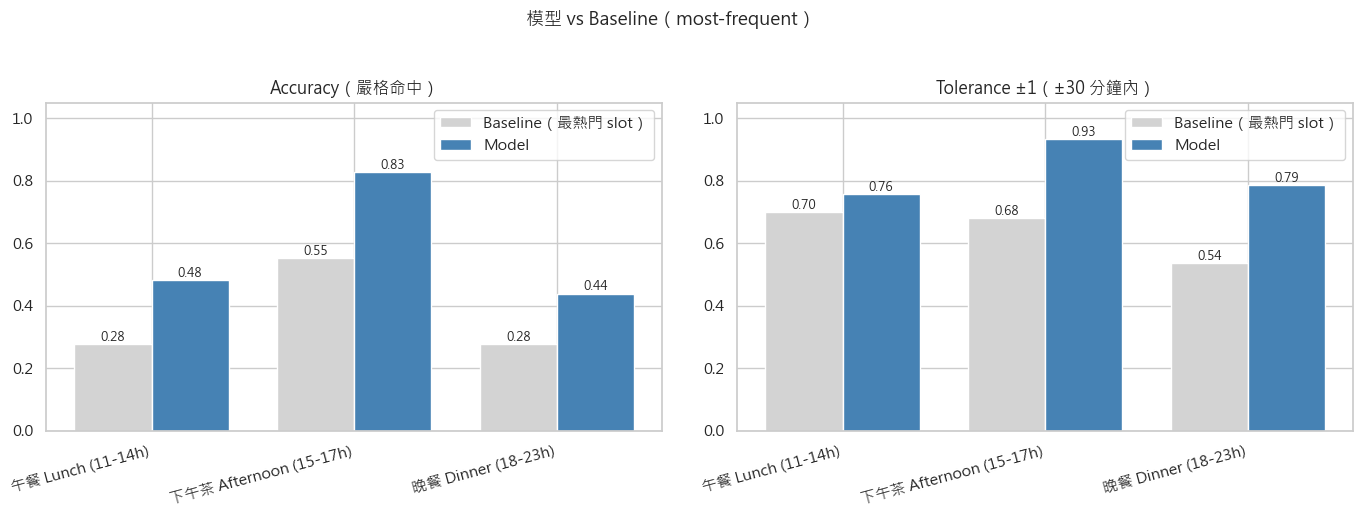

In [5]:
# 模型 vs Baseline 視覺化（不含整體列）
plot_df = summary[summary["子集 Subset"] != "整體 Overall"]
names = plot_df["子集 Subset"].tolist()
x = np.arange(len(names)); w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, base_col, model_col) in zip(
    axes,
    [("Accuracy（嚴格命中）", "Baseline Acc", "Model Acc"),
     (f"Tolerance ±{TOL}（±{TOL*30} 分鐘內）", f"Baseline Tol±{TOL}", f"Model Tol±{TOL}")],
):
    ax.bar(x - w/2, plot_df[base_col], w, label="Baseline（最熱門 slot）", color="lightgray")
    ax.bar(x + w/2, plot_df[model_col], w, label="Model", color="steelblue")
    for i in range(len(names)):
        ax.text(i - w/2, plot_df[base_col].iloc[i] + 0.01, f"{plot_df[base_col].iloc[i]:.2f}", ha="center", fontsize=9)
        ax.text(i + w/2, plot_df[model_col].iloc[i] + 0.01, f"{plot_df[model_col].iloc[i]:.2f}", ha="center", fontsize=9)
    ax.set_title(title); ax.set_ylim(0, 1.05)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
    ax.legend()

fig.suptitle("模型 vs Baseline（most-frequent）", y=1.03, fontsize=13)
fig.tight_layout(); plt.show()

## 4. 混淆矩陣（逐子集）

座標以可讀時段標示（如 `11:00`、`11:30`）。對角線越亮代表預測越準。

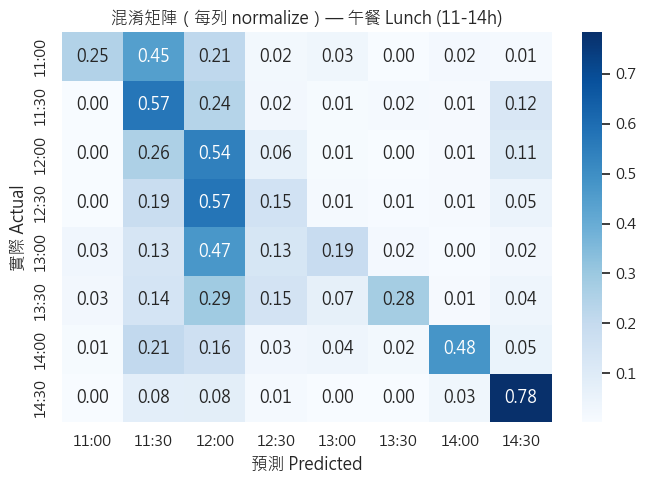

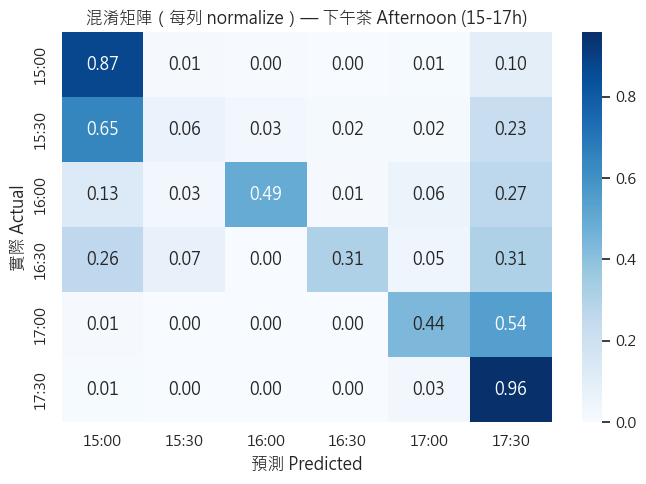

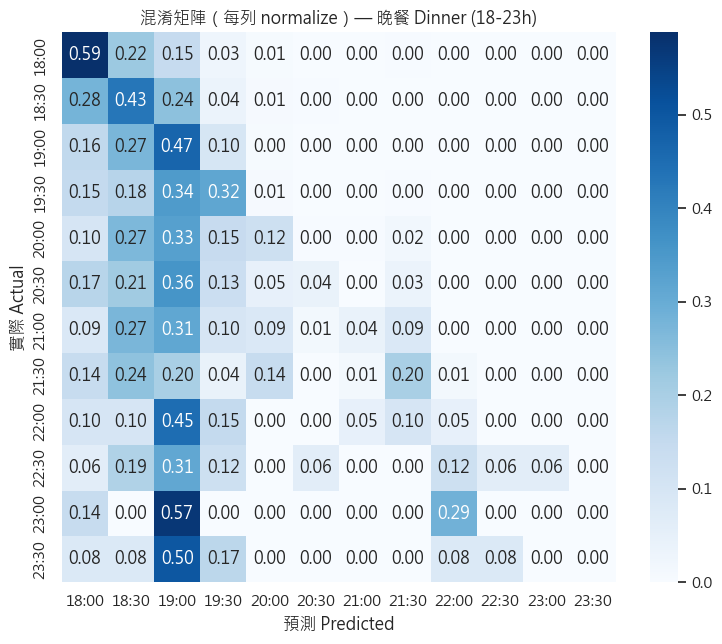

In [6]:
for name, r in results.items():
    yt, yp = r["y_true"], r["y_pred"]
    labels = sorted(set(yt) | set(yp))
    cm = confusion_matrix(yt, yp, labels=labels).astype(float)
    cm_norm = np.nan_to_num(cm / cm.sum(axis=1, keepdims=True))
    ticks = [slot_label(s) for s in labels]

    fig, ax = plt.subplots(figsize=(max(7, len(labels) * 0.65), max(5, len(labels) * 0.55)))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=ticks, yticklabels=ticks, ax=ax)
    ax.set_xlabel("預測 Predicted"); ax.set_ylabel("實際 Actual")
    ax.set_title(f"混淆矩陣（每列 normalize）— {name}")
    plt.tight_layout(); plt.show()

## 5. 容忍度分析

slot 是有序的時間軸，因此「差幾個 slot」本身就有意義。下圖比較**模型**與 **baseline** 在放寬容忍度時的 accuracy。

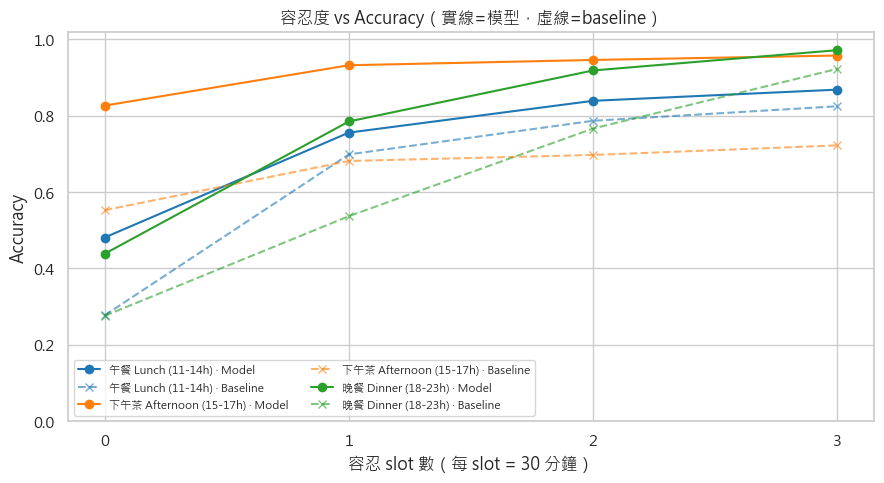

In [7]:
tols = [0, 1, 2, 3]
fig, ax = plt.subplots(figsize=(9, 5))
palette = plt.cm.tab10.colors
for i, (name, r) in enumerate(results.items()):
    model_y = [tolerance_accuracy(r["y_true"], r["y_pred"], tolerance=t) for t in tols]
    base_y = [tolerance_accuracy(r["y_true"], r["y_base"], tolerance=t) for t in tols]
    ax.plot(tols, model_y, marker="o", color=palette[i], label=f"{name} · Model")
    ax.plot(tols, base_y, marker="x", ls="--", color=palette[i], alpha=0.6, label=f"{name} · Baseline")
ax.set_xticks(tols)
ax.set_xlabel("容忍 slot 數（每 slot = 30 分鐘）"); ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.02); ax.set_title("容忍度 vs Accuracy（實線=模型，虛線=baseline）")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 6. 誤差分析

`預測誤差 = 預測 slot − 實際 slot`。0 表完全命中，±1 表差一個 30 分鐘 slot。

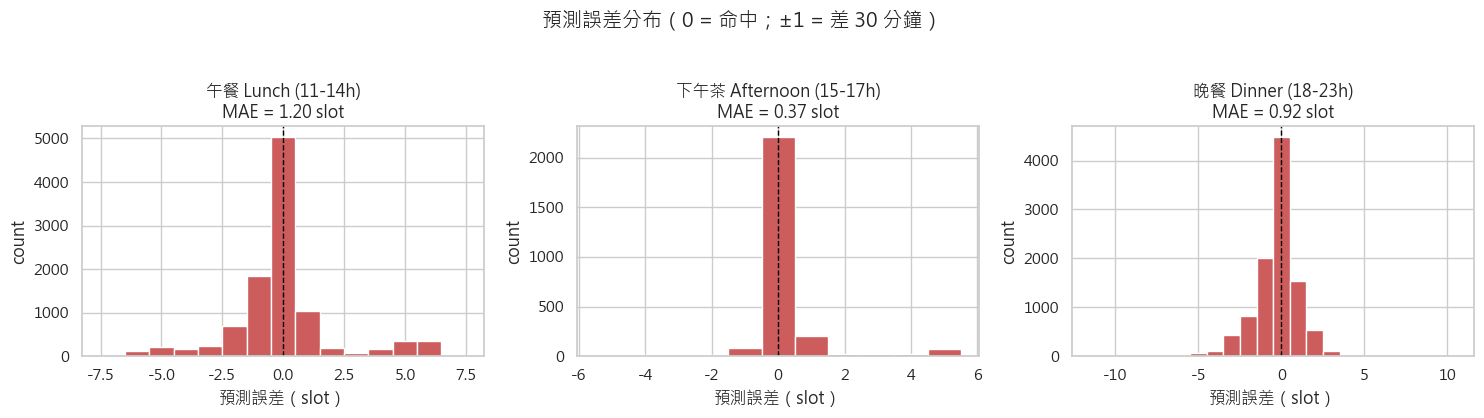

In [8]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    err = np.array(r["y_pred"]) - np.array(r["y_true"])
    bins = np.arange(err.min() - 0.5, err.max() + 1.5, 1)
    ax.hist(err, bins=bins, color="indianred", edgecolor="white")
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_title(f"{name}\nMAE = {np.mean(np.abs(err)):.2f} slot")
    ax.set_xlabel("預測誤差（slot）"); ax.set_ylabel("count")
fig.suptitle("預測誤差分布（0 = 命中；±1 = 差 30 分鐘）", y=1.04)
plt.tight_layout(); plt.show()

In [9]:
# 最常見的混淆配對（實際 -> 預測）
for name, r in results.items():
    yt, yp = np.array(r["y_true"]), np.array(r["y_pred"])
    mask = yt != yp
    print(f"=== {name} — 最常見混淆（實際 → 預測）===")
    if mask.sum() == 0:
        print("  無錯誤\n"); continue
    pairs = pd.Series(list(zip(yt[mask], yp[mask]))).value_counts().head(5)
    for (a, b), c in pairs.items():
        print(f"  {slot_label(a)} → {slot_label(b)} : {c} 次")
    print()

=== 午餐 Lunch (11-14h) — 最常見混淆（實際 → 預測）===
  12:30 → 12:00 : 901 次
  12:00 → 11:30 : 753 次
  11:30 → 12:00 : 675 次
  11:30 → 14:30 : 351 次
  13:00 → 12:00 : 310 次

=== 下午茶 Afternoon (15-17h) — 最常見混淆（實際 → 預測）===
  17:00 → 17:30 : 187 次
  15:00 → 17:30 : 68 次
  15:30 → 15:00 : 40 次
  17:30 → 17:00 : 39 次
  16:00 → 17:30 : 18 次

=== 晚餐 Dinner (18-23h) — 最常見混淆（實際 → 預測）===
  18:30 → 18:00 : 743 次
  18:30 → 19:00 : 651 次
  19:00 → 18:30 : 637 次
  18:00 → 18:30 : 631 次
  19:30 → 19:00 : 550 次



## 7. 特徵重要性（逐子集）

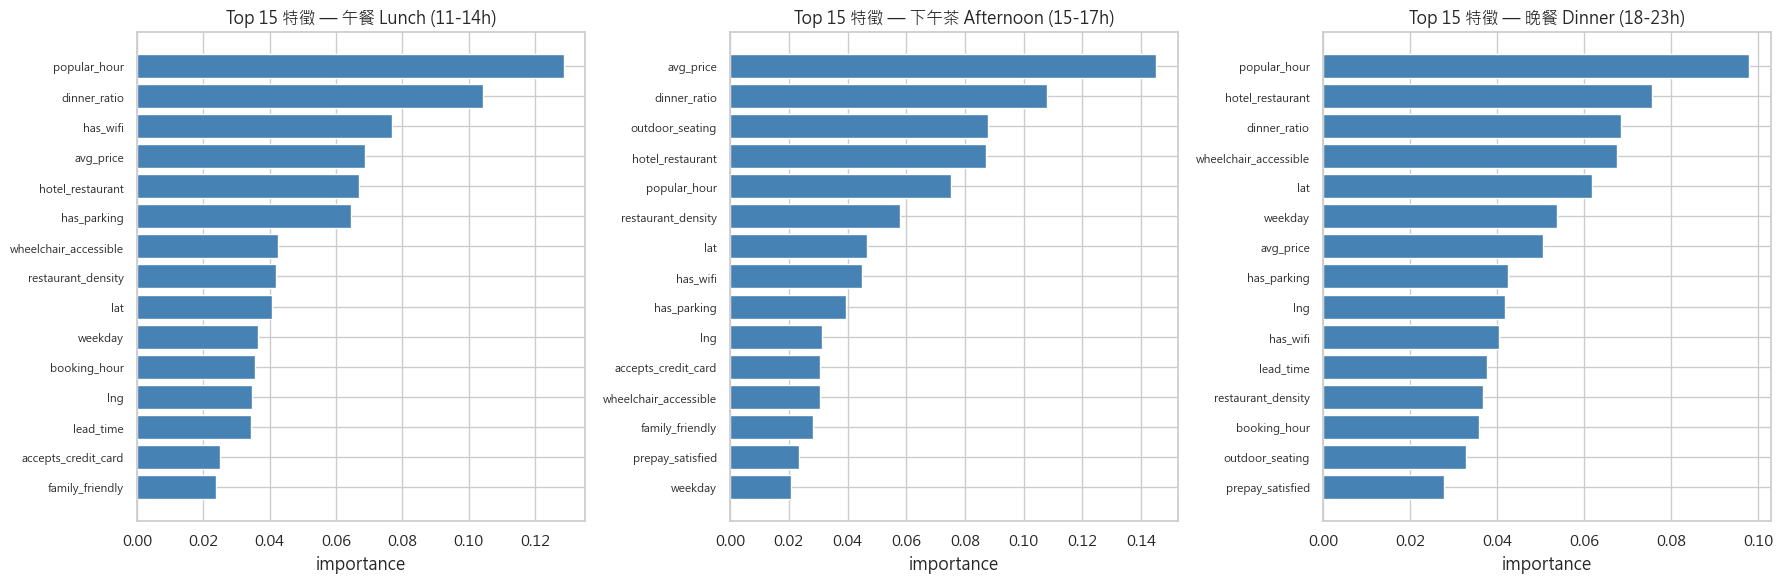

In [10]:
TOP_N = 15
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    imp = (pd.DataFrame({"feature": r["feature_names"],
                         "importance": r["model"].feature_importances_})
           .sort_values("importance", ascending=False).head(TOP_N))
    ax.barh(range(len(imp)), imp["importance"], color="steelblue")
    ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp["feature"], fontsize=8)
    ax.invert_yaxis(); ax.set_title(f"Top {TOP_N} 特徵 — {name}"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

## 8. Leakage Sanity Check

確認模型特徵中**不含**會直接洩漏答案的時間欄位
（`reservation_hour` / `reservation_seconds` 為 leakage，`reservation_half_hour` 為目標本身）。
這正是先前 `xgboost.ipynb` 第一段「完美預測」的成因——此處驗證 production 模型沒有這個問題。

In [11]:
leaky = {"reservation_hour", "reservation_seconds", "reservation_half_hour"}
feats = set(next(iter(results.values()))["feature_names"])
intersect = leaky & feats

print("模型實際使用特徵數:", len(feats))
print("特徵中是否含 leakage / 目標欄位:", intersect if intersect else "無（已正確排除）✅")
assert not intersect, f"發現洩漏欄位仍在特徵中: {intersect}"
print("\n所有特徵：")
print(sorted(feats))

模型實際使用特徵數: 25
特徵中是否含 leakage / 目標欄位: 無（已正確排除）✅

所有特徵：
['accepts_credit_card', 'account_gender', 'age', 'avg_price', 'booked_by_gender', 'booking_hour', 'days_from_payday', 'dining_purpose', 'dinner_ratio', 'family_friendly', 'has_parking', 'has_wifi', 'hotel_restaurant', 'is_holiday_vicinity', 'is_vip_member', 'lat', 'lead_time', 'lng', 'outdoor_seating', 'party_size', 'popular_hour', 'prepay_satisfied', 'restaurant_density', 'weekday', 'wheelchair_accessible']


## 9. 結論

- 三個子集的模型表現**全面優於 baseline（最熱門 slot 猜測）**，代表模型確實從特徵中學到了有效訊號，而非只是猜眾數。
- **下午茶 (15–17h)** 表現最佳（accuracy ≈ 0.83、tol±1 ≈ 0.93），因時段集中、類別少。
- **午餐 (11–14h) / 晚餐 (18–23h)** 嚴格 accuracy ≈ 0.44–0.48，但 **tol±1 acc ≈ 0.76–0.79**——
  多數預測落在實際時段的 ±30 分鐘內，以訂位場景而言實用性仍高，且明顯領先 baseline。
- Leakage sanity check 通過：特徵中無時間洩漏欄位，accuracy 落在合理區間。

**可改進方向**：晚餐/午餐類別多且分布不均，可考慮 (1) 針對尾端時段做 class weight / 重採樣、
(2) Optuna 調參（config 已預留 `tuning` 區塊）、(3) 評估是否以 tol±1 作為主要優化目標。